<a href="https://colab.research.google.com/github/vitoriaayres/NOTEBOOKS_COMPILADOS/blob/main/Linear_Regression_from_scratch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
x_sample= np.linspace(1,15,100)
noise1= np.random.uniform(-0.3, 0.3, size=(100))
noise2= np.random.uniform(-20, 20, size=(100))
y_sample= 4*x_sample + 200
y_sample= y_sample + noise2
x_sample= x_sample + noise1

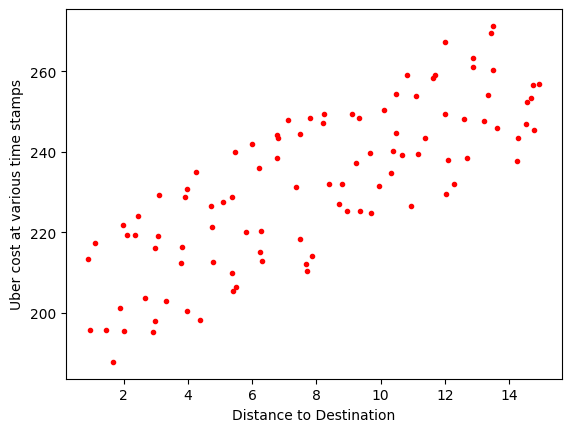

In [4]:
plt.xlabel("Distance to Destination")
plt.ylabel("Uber cost at various time stamps")
plt.plot(x_sample,y_sample, ".r")

In [5]:
def linear_function(m,c,x):
  return m*x+c

In [6]:
def error(m, c, x_sample, y_sample):
  return np.sum((linear_function(m,c,x_sample) - y_sample)**2/len(x_sample))

In [7]:
def derrivative_of_error_m(m,c,x_sample,y_sample):
  derrivative= 2*np.sum((y_sample - linear_function(m,c,x_sample))*x_sample)
  return derrivative/len(x_sample)

def derrivative_of_error_c(m,c,x_sample,y_sample):
  derrivative= -2 * np.sum(y_sample - linear_function(m,c,x_sample))
  return derrivative/len(x_sample)

In [14]:
class GradientDescent():
  def __init__(self,m,c, learning_rate):
    self.m = 0
    self.c = 0
    self.error = 10000
    self.learning_rate = learning_rate
    self.error_log = []
    self.m_log = []
    self.c_log = []
    self.dm_log = []
    self.dc_log = []
  def optimize(self, x_sample,y_sample, threshold = 10):
    num_iter = 0
    while(self.error> threshold and num_iter <10000):
      num_iter = num_iter+1
      self.error = error(self.m, self.c, x_sample, y_sample)
      dm = self.learning_rate*(derrivative_of_error_m(self.m, self.c, x_sample, y_sample))
      dc = self.learning_rate*(derrivative_of_error_c(self.m, self.c, x_sample, y_sample))
      self.m = self.m - dm
      self.c = self.c - dc

      self.m_log.append(self.m)
      self.c_log.append(self.c)
      self.dm_log.append(dm)
      self.dc_log.append(dc)
      self.error_log.append(self.error)

      print("Current Loss:\t %f" %self.error)
      print("Current  Value:\n\tm:\t%f\n\tc:\t%f" %(self.m,self.c))
        print("_"*100)

In [ ]:
initial_m= 0
initial_c= 0
learning_rate= 0.01
alg= GradientDescent(initial_m, initial_c, learning_rate)
alg.optimize(x_sample,y_sample,200)

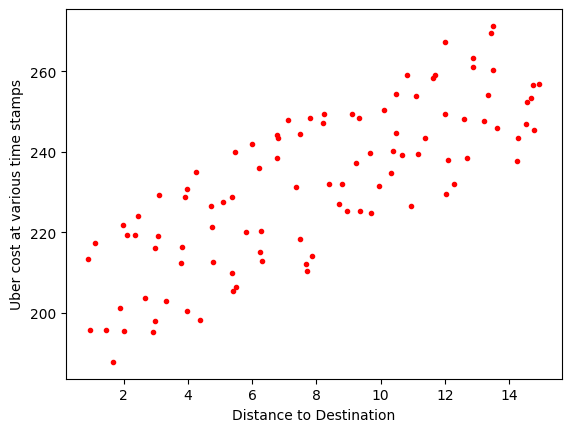

In [16]:
plt.xlabel("Distance to Destination")
plt.ylabel("Uber cost at various time stamps")
plt.plot(x_sample,y_sample, ".r")


x = np.linspace(1,15,100)
y = linear_function(alg.m,alg.c,x)
plt.plot(x,y,"-b")

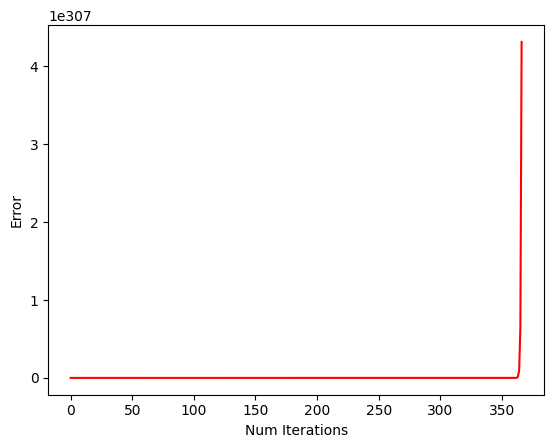

In [18]:
plt.xlabel("Num Iterations")
plt.ylabel("Error")
plt.plot(alg.error_log, 'r-')

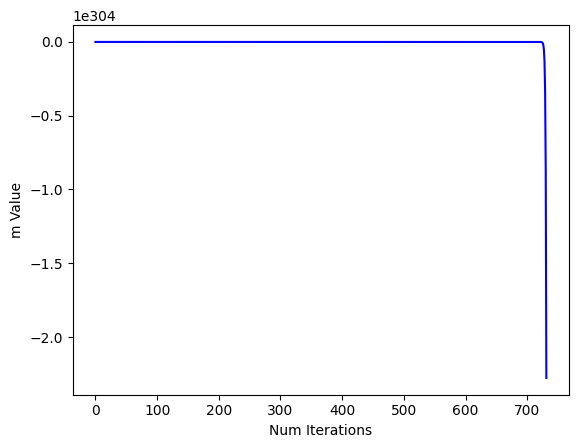

In [19]:
plt.xlabel("Num Iterations")
plt.ylabel("m Value")
plt.plot(alg.m_log, 'b-')